<a href="https://colab.research.google.com/github/ashwini-mohidekar/neural-networks-basics/blob/main/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pylab as plt

In [29]:
# Define a transform to normalize the data
transform = transforms.ToTensor()

# Download and load the training data
train_images = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_images = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_images, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_images, batch_size=64, shuffle=True)

##Analyzing the Dataset

Confirm type and dimensions of the dataset

In [12]:
train_images.data.shape

torch.Size([60000, 28, 28])

In [13]:
test_images.data.shape

torch.Size([10000, 28, 28])

How many instances do we have of each of the different classes?

In [14]:
np.unique(train_images.targets, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [15]:
class_names = ['T-shirt/top', 'Trouser' , 'Pullover', 'Dress', 'Coat', 'Sandal' , 'Shirt' , 'Sneaker' , 'Bag' , 'Ankle boot']

In [16]:
#Get 16 images at random
import random
random.seed(1)
train_idx = list(range(len(train_images)))
sampler = random.sample(train_idx , 16)
sampler

[8805,
 37303,
 55537,
 52577,
 50054,
 4135,
 16716,
 7727,
 32468,
 49870,
 29457,
 30949,
 42702,
 24878,
 51689,
 13759]

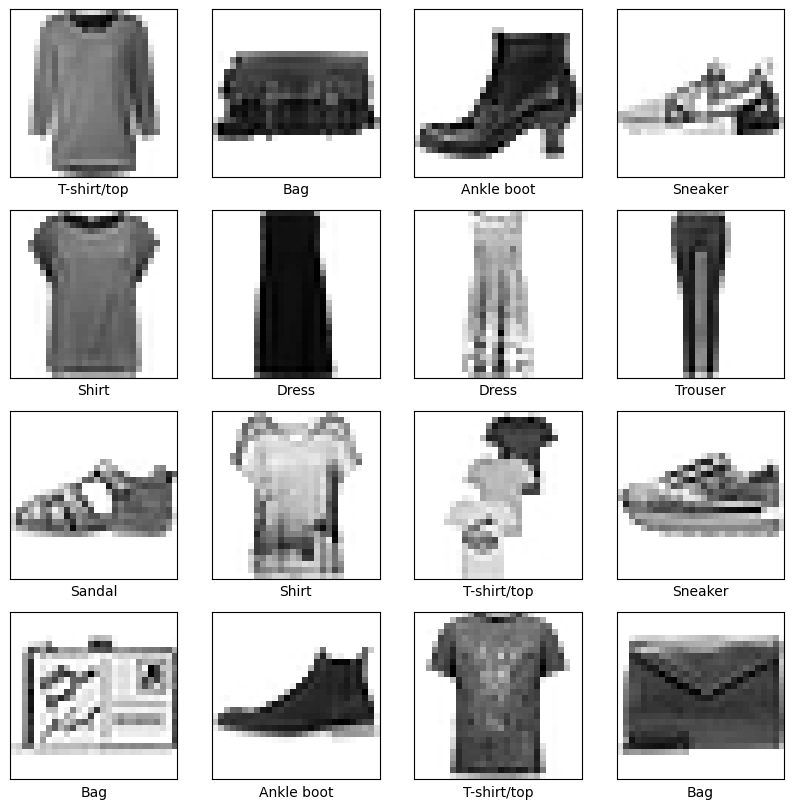

In [17]:
plt.figure(figsize=(10,10))
for i, idx in enumerate(sampler):
  image, label = train_images[idx]
  plt.subplot(4,4,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(image.squeeze(), cmap=plt.cm.binary)
  plt.xlabel(class_names[label])
plt.show()

What does one image look like?

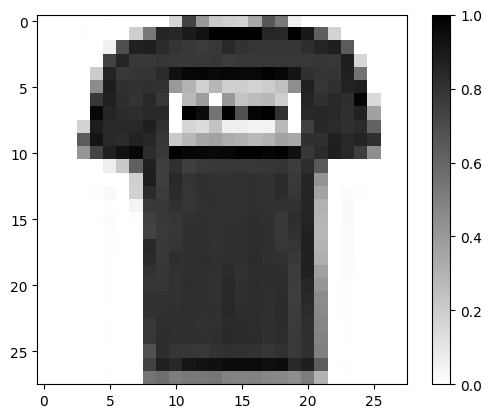

In [18]:
random_image_id = 1
image, label = train_images[random_image_id]
plt.figure()
plt.imshow(image.squeeze(), cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

In [19]:
class_names[label]

'T-shirt/top'

In [20]:
train_images[random_image_id][0].shape

torch.Size([1, 28, 28])

In [21]:
train_images[random_image_id]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000,
           0.0000, 0.0000, 0.1608, 0.7373, 0.4039, 0.2118, 0.1882, 0.1686,
           0.3412, 0.6588, 0.5216, 0.0627, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.1922,
           0.5333, 0.8588, 0.8471, 0.8941, 0.9255, 1.0000, 1.0000, 1.0000,
           1.0000, 0.8510, 0.8431, 0.9961, 0.9059, 0.6275, 0.1765, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0549, 0.6902, 0.8706,
           0.8784, 0.8314, 0.7961, 0.7765, 0.7686, 0.7843, 0.8431, 0.8000,
           0.7922, 0.7882, 0.7882, 0.7882, 0.8196, 0.8549, 0.8784, 0.6431,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7373, 0.8588, 0.7843,
           0.7765, 0.7922, 0.7765, 0.7804, 0.7804, 0.7882, 0.7686, 0.7765,
           0.7765, 0.7843, 0.7843, 0.7843, 

##Defining the Neural Network

In [22]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [23]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(28 * 28, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 10)
).to(device)

In [24]:
import torch.nn.functional as F

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        # Define the layers of the network
        self.flatten = torch.nn.Flatten()
        self.fc1 = torch.nn.Linear(28 * 28, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 10)

    def forward(self, x):
        # Define the forward pass
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # No activation on the final layer for raw logits
        return x

# Create an instance of the model and move it to the desired device
model = NeuralNetwork().to(device)

##Loss

In [25]:
loss_function = torch.nn.CrossEntropyLoss()

##Optimizer

In [26]:
optimizer = torch.optim.Adam(model.parameters())

##Before we train the Neural Network

In [30]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pylab as plt
import torch.nn.functional as F

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        # Define the layers of the network
        self.flatten = torch.nn.Flatten()
        self.fc1 = torch.nn.Linear(28 * 28, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 10)

    def forward(self, x):
        # Define the forward pass
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = NeuralNetwork().to(device)

Using cuda device


In [31]:
# Define a transform to normalize the data
transform = transforms.ToTensor()

# Download and load the training data
train_images = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_images = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_images, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_images, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

epochs = 30

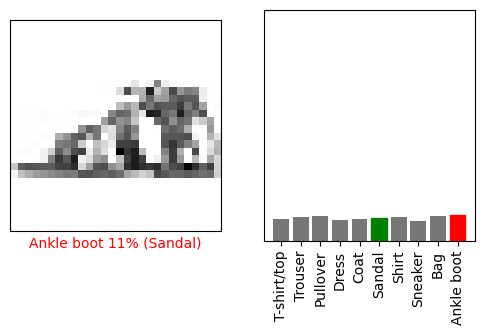

In [33]:
image_id = 11 # Pick an image id between 0 and 9999 inclusive

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)



# Get a single image and its corresponding label
img = images[image_id].to(device)
true_label = labels[image_id].to(device)

# Make a prediction
with torch.no_grad():
    logits = model(img.unsqueeze(0)) # We extract a single test image. Get raw prediction scores (logits)

ps = torch.nn.functional.softmax(logits, dim=1).cpu() #convert those to probabilities using the exponential function, and identify the predicted class.
predictions = ps.numpy()[0]
predicted_label = np.argmax(predictions)

def plot_image(predictions_array, true_label, img):
  '''The visualization functions help interpret model behavior by showing not just what it predicted, but how confident it was about each possible class.'''
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img.cpu().numpy().squeeze(), cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'green'
  else:
    color = 'red'

  plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})", color=color)

def plot_value_array(predictions_array, true_label):
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('green')

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(predictions, true_label.item(), img)
plt.subplot(1,2,2)
plot_value_array(predictions,  true_label.item())
_ = plt.xticks(range(10), class_names, rotation=90)
plt.show()

##Training the Neural Network

In [34]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pylab as plt
import torch.nn.functional as F

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        # Define the layers of the network
        self.flatten = torch.nn.Flatten()
        self.fc1 = torch.nn.Linear(28 * 28, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 10)

    def forward(self, x):
        # Define the forward pass
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # No activation on the final layer for raw logits
        return x

# Create an instance of the model and move it to the desired device
model = NeuralNetwork().to(device)

Using cuda device


In [35]:
# Define a transform to normalize the data
transform = transforms.ToTensor()

# Download and load the training data
train_images = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_images = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_images, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_images, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

epochs = 30

In [36]:
loss_function = torch.nn.CrossEntropyLoss()

In [37]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [38]:
model.train()

epochs = epochs
for epoch in range(epochs):
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images) # 1. Forward Pass
        loss = loss_function(output, labels) #2.  Calculate Loss
        loss.backward() # 3. Backward Pass
        optimizer.step() # 4. Optimizer Step

        running_loss += loss.item()
    print(f"Epoch {epoch+1} - Training loss: {running_loss/len(train_loader)}")

Epoch 1 - Training loss: 0.5640383553403273
Epoch 2 - Training loss: 0.3933799896063581
Epoch 3 - Training loss: 0.3561054972061979
Epoch 4 - Training loss: 0.32759704232724235
Epoch 5 - Training loss: 0.3080450152553348
Epoch 6 - Training loss: 0.2935707862300278
Epoch 7 - Training loss: 0.28165589636767596
Epoch 8 - Training loss: 0.26898948443151993
Epoch 9 - Training loss: 0.2599208597133536
Epoch 10 - Training loss: 0.24957945125936065
Epoch 11 - Training loss: 0.2422526638184402
Epoch 12 - Training loss: 0.23385815621057807
Epoch 13 - Training loss: 0.22451229547577373
Epoch 14 - Training loss: 0.2190173407400976
Epoch 15 - Training loss: 0.21191651420171326
Epoch 16 - Training loss: 0.20508642254798398
Epoch 17 - Training loss: 0.20112361812562957
Epoch 18 - Training loss: 0.19503413129653505
Epoch 19 - Training loss: 0.1858711437717366
Epoch 20 - Training loss: 0.18337239898137572
Epoch 21 - Training loss: 0.1775568339572564
Epoch 22 - Training loss: 0.17457171290048532
Epoch 2

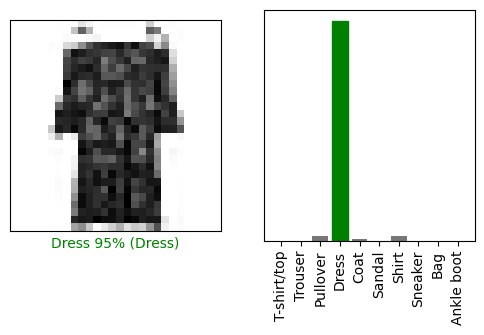

In [43]:
image_id = 33 # Pick an image id between 0 and 9999 inclusive

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)



# Get a single image and its corresponding label
img = images[image_id].to(device)
true_label = labels[image_id].to(device)

# Make a prediction
with torch.no_grad(): #This tells PyTorch we are only doing inference (predicting), not training, so it doesn't need to keep track of gradients.
                      #This makes the process faster and uses less memory.
    logits = model(img.unsqueeze(0)) # We extract a single test image, pass it through the model to get raw prediction scores (logits)

ps = torch.nn.functional.softmax(logits, dim=1).cpu() #convert those to probabilities using the exponential function, and identify the predicted class.
predictions = ps.numpy()[0]
predicted_label = np.argmax(predictions) #Finally, np.argmax() finds the index of the class with the highest probability, which becomes our model's final prediction.

#The visualization functions help interpret model behavior by showing not just what it predicted, but how confident it was about each possible class.
def plot_image(predictions_array, true_label, img):
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img.cpu().numpy().squeeze(), cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'green'
  else:
    color = 'red'

  plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})", color=color)

def plot_value_array(predictions_array, true_label):
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('green')

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(predictions, true_label.item(), img)
plt.subplot(1,2,2)
plot_value_array(predictions,  true_label.item())
_ = plt.xticks(range(10), class_names, rotation=90)
plt.show()

##Testing the Neural Network Model

In [44]:
test_loader = torch.utils.data.DataLoader(test_images, batch_size=64, shuffle=False)
loss_function = torch.nn.CrossEntropyLoss()

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

test(test_loader, model, loss_function)

Test Error: 
 Accuracy: 89.0%, Avg loss: 0.394304 

